In [1]:
from collections import defaultdict
import pickle
import copy

def merge_and_filter_distortion_types(border_cam_distorted, ID, OOD):
    # Create a new dictionary to store the filtered and renamed data
    filtered_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

    for cam_type, views_dict in border_cam_distorted.items():
        for view, distortion_dict in views_dict.items():
            if view == ID:
                target_view = 'id'
            elif view == OOD:
                target_view = 'ood'
            else:
                continue  # Skip views that are neither ID nor OOD

            # Create an empty dictionary to accumulate merged distortions
            merged_distortions = defaultdict(dict)

            for distortion_type, severities_dict in distortion_dict.items():
                for severity, data in severities_dict.items():
                    # Merge the dictionaries for each severity level
                    if severity not in merged_distortions:
                        merged_distortions[severity] = copy.deepcopy(data)
                    else:
                        merged_distortions[severity].update(data)

            # Add the merged distortions under the target view key
            filtered_dict[cam_type][target_view] = dict(merged_distortions)

    return {k: dict(v) for k, v in filtered_dict.items()}

import pandas as pd

def transform_to_dataframe(data_dict, view_name, cam_type_mapping):
    rows = []
    
    for cam_type, views_dict in data_dict.items():
        for view, severities_dict in views_dict.items():
            for severity, values in severities_dict.items():
                for key, value in values.items():
                    # Create a row for each key-value pair
                    rows.append({
                        "CAM type": cam_type_mapping[cam_type],
                        "Severity": severity,
                        "View": view_name,  # Input view name
                        "Data": view,       # 'id' or 'ood'
                        "Values": value
                    })

    # Create a DataFrame from the rows
    df = pd.DataFrame(rows)
    return df

In [2]:
views = ['f', 'r', 'er', 'fx']
view_mapping = {'f': 'Full', 'r': 'Restricted', 'er': 'Extra R.', 'fx': 'Fixed'}
all_df = pd.DataFrame()
for view in views:
    border_cam_distorted_path = f"../logs/combined_{view}_combined/border_cam_distorted.pkl"
    with open(border_cam_distorted_path, 'rb') as f:
        border_cam_distorted = pickle.load(f)
    new_dict = merge_and_filter_distortion_types(border_cam_distorted, f'test_{view}', 'cr')
    cam_type_mapping = {'ic': 'Object', 'bc': 'Edge', 'ec': 'Background'}

    new_df = transform_to_dataframe(new_dict, view_mapping[view], cam_type_mapping)
    all_df = pd.concat([all_df, new_df])

In [19]:
import matplotlib.colors as mcolors

def generate_saturation_palette(base_color, levels):
    """
    Generates a palette where saturation decreases with increasing severity.

    Args:
        base_color (str): The base color in hex format (e.g., '#C40F5B').
        levels (int): Number of severity levels.

    Returns:
        dict: A dictionary mapping severity levels to hex colors.
    """
    # Convert the base color to HLS (Hue, Lightness, Saturation)
    base_hls = mcolors.rgb_to_hsv(mcolors.hex2color(base_color))
    palette = {}

    for severity in range(1, levels + 1):
        # Decrease the saturation progressively
        adjusted_saturation = base_hls[1] * (1 - (severity - 1) / (levels - 1))
        # Generate the new color with adjusted saturation
        adjusted_color = mcolors.hsv_to_rgb((base_hls[0], adjusted_saturation, base_hls[2]))
        # Convert it back to hex
        palette[severity] = mcolors.rgb2hex(adjusted_color)

    return palette
levels = 5

# Generate the palette
palette_object = generate_saturation_palette('#C40F5B', levels)
palette_edge = generate_saturation_palette('#B10026', levels)
palette_background = generate_saturation_palette('#089099', levels)

In [20]:
dll_df = all_df.reset_index()
order = ['Fixed', 'Extra R.', 'Restricted', 'Full']
dll_df['View'] = pd.Categorical(dll_df['View'], categories=order, ordered=True)

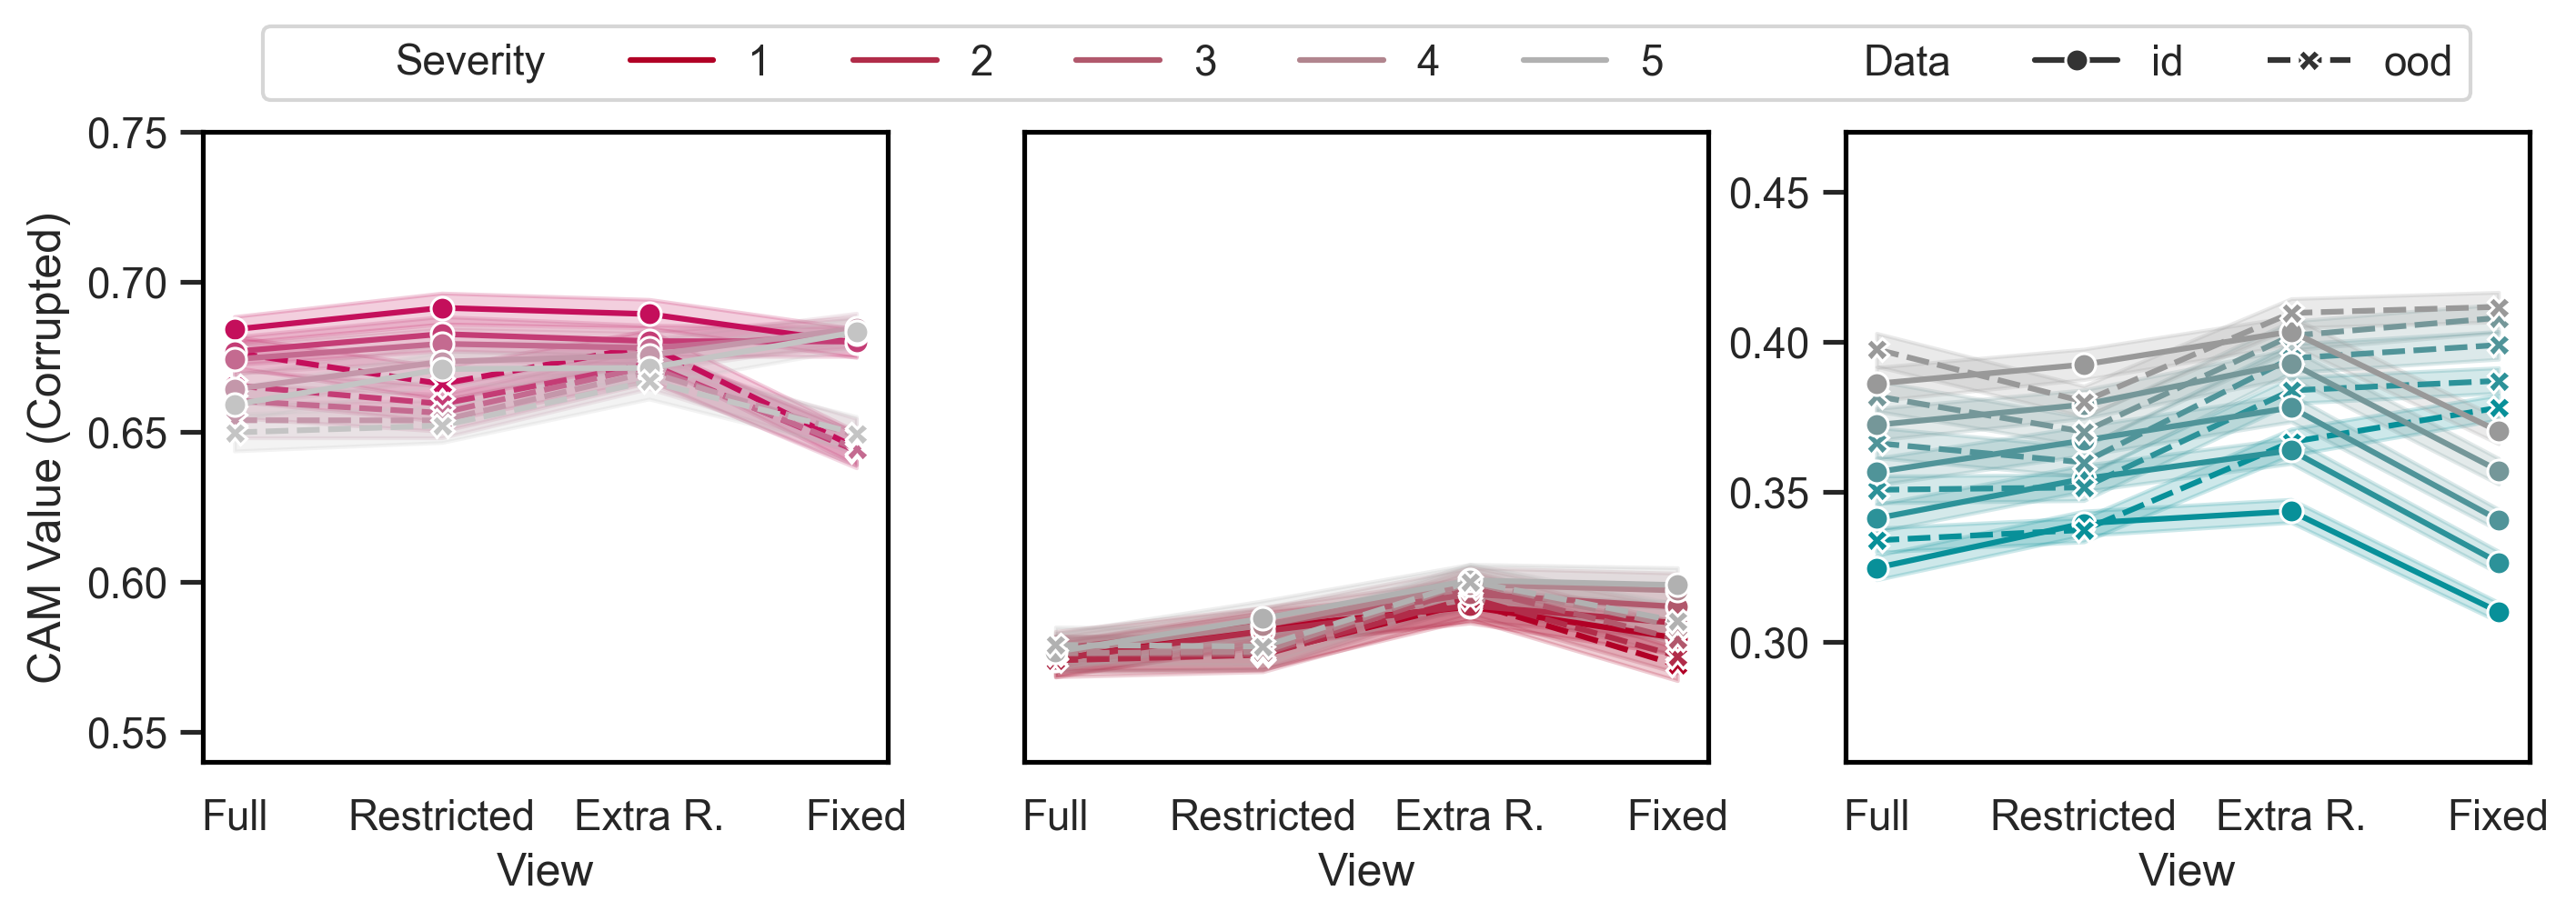

In [21]:
from matplotlib.ticker import FormatStrFormatter
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['ytick.left'] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = '500'  # medium weight
plt.rcParams['font.stretch'] = 'semi-expanded'  # slightly expanded
plt.rcParams['figure.dpi'] = 300
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(11, 3))

df_ic = all_df[all_df['CAM type'] == 'Object']
df_bc = all_df[all_df['CAM type'] == 'Edge']
df_ec = all_df[all_df['CAM type'] == 'Background']

df_ic = df_ic.reset_index()
sns.lineplot(
    ax=ax1,
    data=df_ic,
    x="View", y="Values", hue="Severity", style='Data', palette=palette_object,
    markers=True, dashes=True,legend=False
)

sns.lineplot(
    ax=ax2,
    data=df_bc,
    x="View", y="Values", hue="Severity", style='Data', palette=palette_edge,
    markers=True, dashes=True,legend=True
)

sns.lineplot(
    ax=ax3,
    data=df_ec,
    x="View", y="Values", hue="Severity", style='Data', palette=palette_background,
    markers=True, dashes=True,legend=False
)

ax1.grid(False)
ax2.grid(False)
ax3.grid(False)
ax2.set_ylabel('')
ax3.set_ylabel('')
ax2.set_yticks([])

ax1.set_ylim([0.54, 0.75])
ax2.set_ylim([0.54, 0.75])
ax3.set_ylim([0.26, 0.47])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_ylabel('CAM Value (Corrupted)')
for ax in [ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=9)
plt.savefig('border_cam_plot_corrupted_by_severity.png', bbox_inches='tight')